In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, root_mean_squared_error

import numpy as np

from sqlalchemy import create_engine
import pymysql

In [2]:
def get_evaluation(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    median_ae = median_absolute_error(y_test, y_pred)

    return [mae, mse, rmse, r2, mape, median_ae]

In [19]:
def save_prediction(y_test, y_predict, file_name):
    y_predict_flat = y_predict.flatten()
    y_predict_series = pd.Series(y_predict_flat, name='Predicted')

    y_test.reset_index(drop=True, inplace=True)
    y_predict_series.reset_index(drop=True, inplace=True)

    combined_df = pd.concat([y_test, y_predict_series], axis=1)
    combined_df.to_csv(file_name, index=False)


In [3]:
username = "root"
password = ""
port = 3306
database = "common"

In [4]:
engine = create_engine('mysql+pymysql://%s@localhost:%i/%s' %(username, port, database))

In [5]:
sql = "SELECT * FROM common.histone_count"
histone_count_df = pd.read_sql_query(sql, engine)

display(histone_count_df.head())
display(histone_count_df.shape)

,h_chrom,tss_start,tss_end,h_chromStart,h_chromEnd,h_gene,h_test_id,h_gene_id,h_locus,h_sample_1,...,n_cdsStartStat,n_cdsEndStat,n_exonFrames,tss,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
0,chr1,27370,31370,14361,29370,WASH7P,XLOC_001251,XLOC_001251,chr1:14361-29370,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,'",29370,0,0,0,0,0,0
1,chr1,34081,38081,34610,36081,FAM138A,XLOC_001252,XLOC_001252,chr1:34610-36081,hepg2_hr2,...,none,none,"b'-1,-1,-1,'",36081,0,0,0,0,0,0
2,chr1,321891,325891,323891,328581,"LOC100132062,LOC100133331",XLOC_000002,XLOC_000002,chr1:323891-328581,hepg2_hr2,...,none,none,"b'-1,-1,-1,'",323891,0,0,0,0,0,0
3,chr1,365658,369658,367658,368597,OR4F29,XLOC_000003,XLOC_000003,chr1:367658-368597,hepg2_hr2,...,cmpl,cmpl,"b'0,'",367658,0,0,0,0,0,0
4,chr1,620034,624034,621095,622034,OR4F29,XLOC_001253,XLOC_001253,chr1:621095-622034,hepg2_hr2,...,cmpl,cmpl,"b'0,'",622034,0,0,0,0,0,0


(2188, 42)


# Data Exploration

In [69]:
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'h_value_1', 'h_value_2']].describe()

,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,h_value_1,h_value_2
count,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000
mean,0.826782,0.637569,0.040219,0.476234,0.137569,20.086062,5.034353
std,2.285053,1.779268,0.226765,1.463434,0.644910,299.367893,86.396701
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.033061,0.029109
max,13.000000,13.000000,4.000000,11.000000,8.000000,5475.900000,3699.890000


### Histogram Analysis

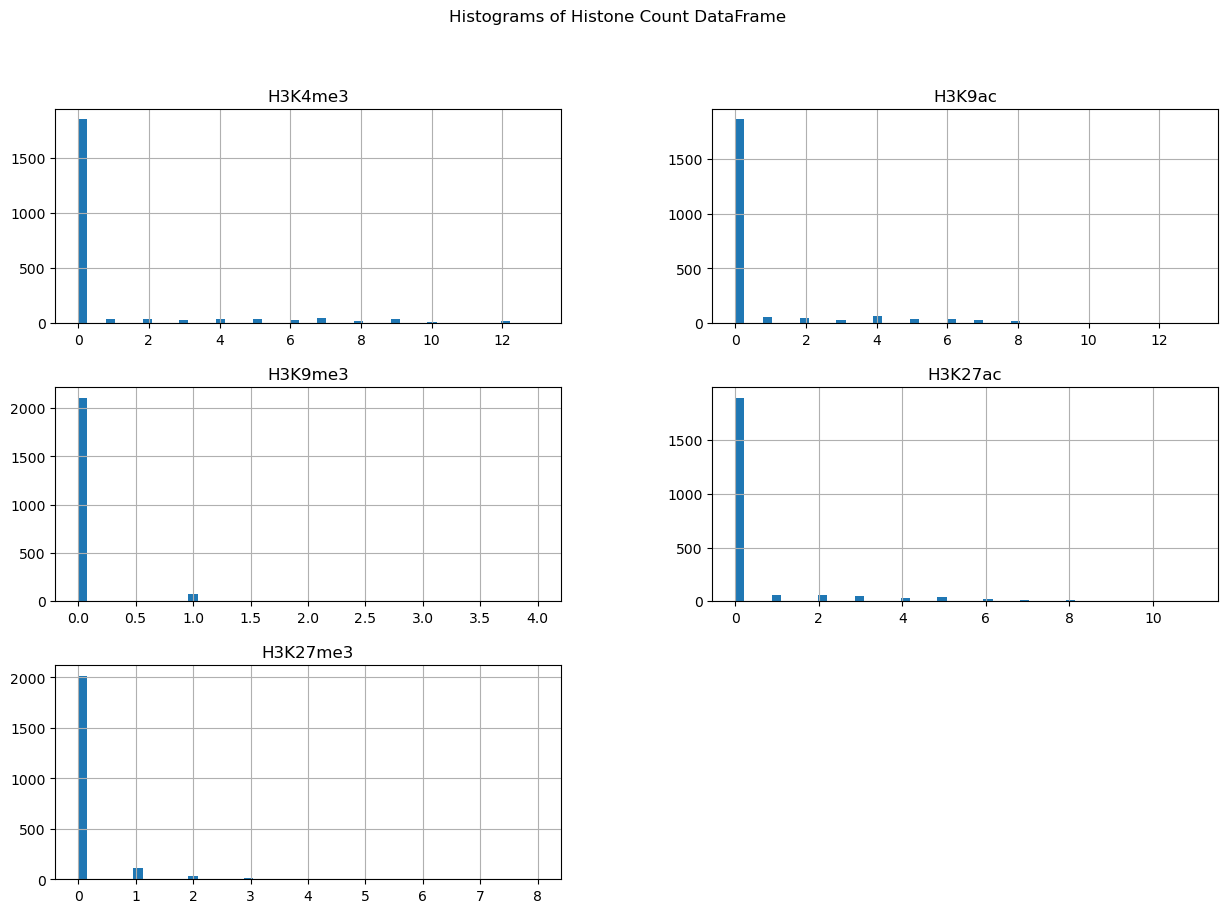

In [171]:
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']].hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms of Histone Count DataFrame')
plt.show()

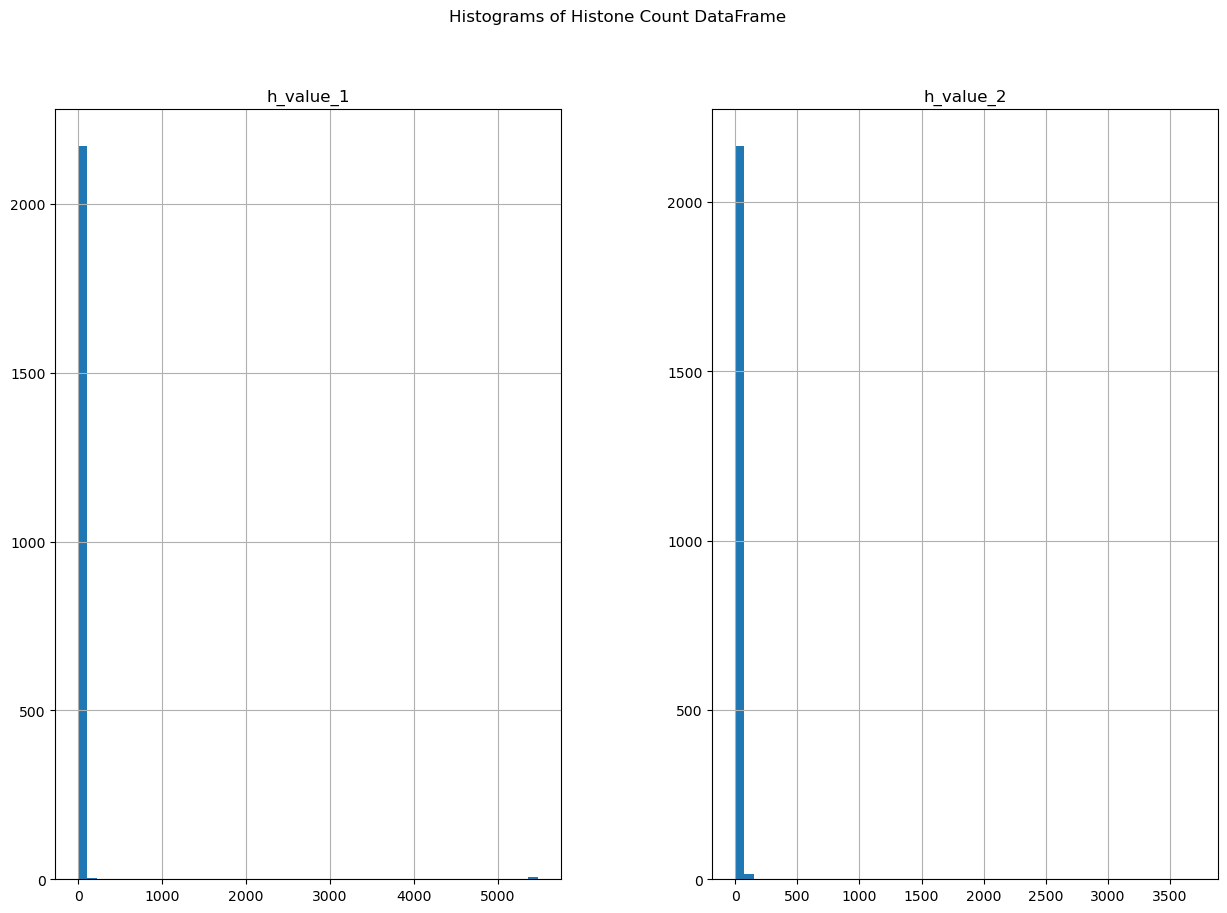

In [170]:
histone_count_df[['h_value_1', 'h_value_2']].hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms of Histone Count DataFrame')
plt.show()

## Boxplot Analysis

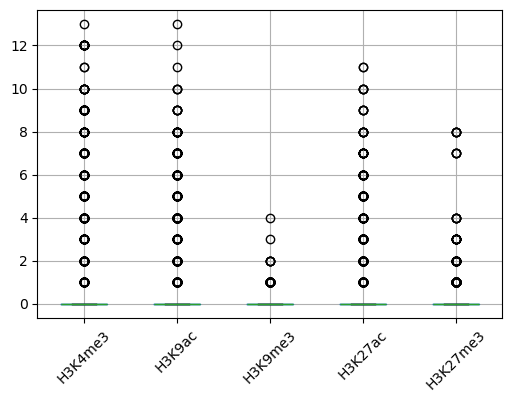

In [49]:
plt.figure(figsize=(6, 4))
histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

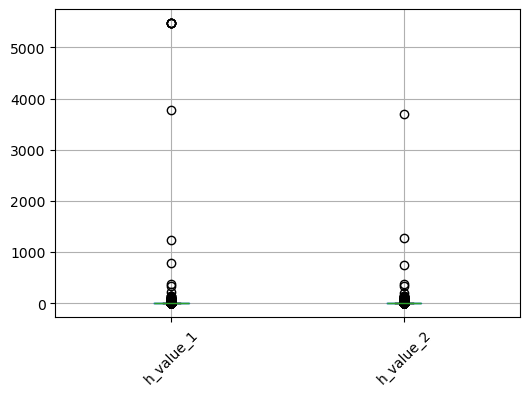

In [50]:
plt.figure(figsize=(6, 4))
histone_count_df[['h_value_1', 'h_value_2']].boxplot()
plt.xticks(rotation=45)
plt.show()

## Plotting Each Feature vs value_1

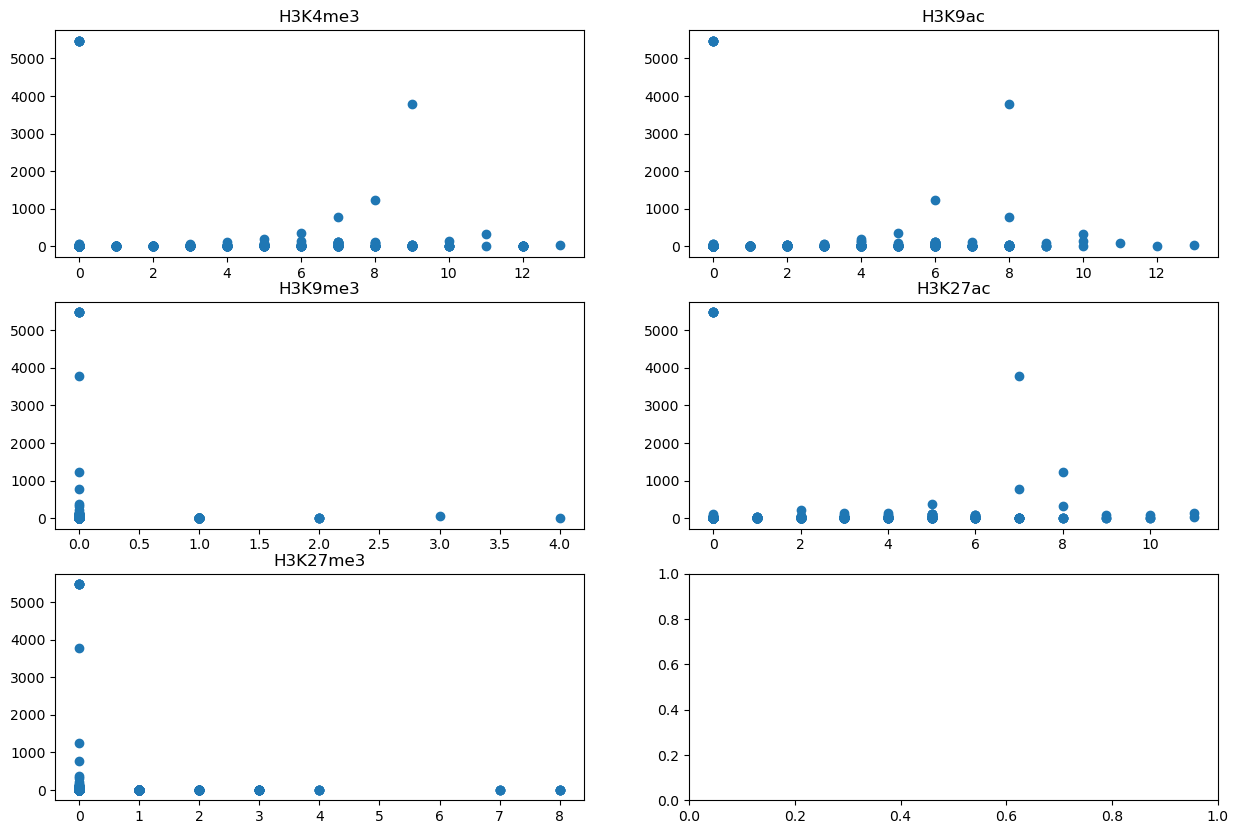

In [67]:
fig, axes = plt.subplots(nrows = 3, ncols=2, figsize = (15, 10))

# ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']
axes[0, 0].scatter(histone_count_df[['H3K4me3']], histone_count_df[['h_value_1']])
axes[0, 0].set_title("H3K4me3")
axes[0, 1].scatter(histone_count_df[['H3K9ac']], histone_count_df[['h_value_1']])
axes[0, 1].set_title("H3K9ac")
axes[1, 0].scatter(histone_count_df[['H3K9me3']], histone_count_df[['h_value_1']])
axes[1, 0].set_title("H3K9me3")
axes[1, 1].scatter(histone_count_df[['H3K27ac']], histone_count_df[['h_value_1']])
axes[1, 1].set_title("H3K27ac")
axes[2, 0].scatter(histone_count_df[['H3K27me3']], histone_count_df[['h_value_1']])
axes[2, 0].set_title("H3K27me3")
plt.show()

# Pre-processing the Dataset

## Outlier Removal

In [142]:
df = histone_count_df

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['h_value_1'].quantile(0.25)
Q3 = df['h_value_1'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound = {lower_bound}, upper bound = {upper_bound}")

# Filter out the outliers
histone_df_filtered = df[(df['h_value_1'] >= lower_bound) & (df['h_value_1'] <= upper_bound)]

# Display the filtered DataFrame
display(histone_df_filtered)
display(histone_df_filtered.shape)

Lower bound = -0.0495912375, upper bound = 0.08265206250000001


,h_chrom,tss_start,tss_end,h_chromStart,h_chromEnd,h_gene,h_test_id,h_gene_id,h_locus,h_sample_1,...,n_cdsStartStat,n_cdsEndStat,n_exonFrames,tss,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,histone_total_count
1,chr1,34081,38081,34610,36081,FAM138A,XLOC_001252,XLOC_001252,chr1:34610-36081,hepg2_hr2,...,none,none,"b'-1,-1,-1,'",36081,0,0,0,0,0,0
2,chr1,321891,325891,323891,328581,"LOC100132062,LOC100133331",XLOC_000002,XLOC_000002,chr1:323891-328581,hepg2_hr2,...,none,none,"b'-1,-1,-1,'",323891,0,0,0,0,0,0
3,chr1,365658,369658,367658,368597,OR4F29,XLOC_000003,XLOC_000003,chr1:367658-368597,hepg2_hr2,...,cmpl,cmpl,"b'0,'",367658,0,0,0,0,0,0
4,chr1,620034,624034,621095,622034,OR4F29,XLOC_001253,XLOC_001253,chr1:621095-622034,hepg2_hr2,...,cmpl,cmpl,"b'0,'",622034,0,0,0,0,0,0
6,chr1,4470110,4474110,4472110,4484744,LOC284661,XLOC_000053,XLOC_000053,chr1:4472110-4484744,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,-1,-1,'",4472110,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,chrY,27244039,27248039,27209229,27246039,TTTY4B,XLOC_030019,XLOC_030019,chrY:27209229-27246039,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,'",27246039,0,0,0,0,0,0
2184,chrY,27328920,27332920,27329789,27330920,TTTY17B,XLOC_030020,XLOC_030020,chrY:27329789-27330920,hepg2_hr2,...,none,none,"b'-1,-1,'",27330920,0,0,0,0,0,0
2185,chrY,27599457,27603457,27601457,27606322,GOLGA2P3Y,XLOC_029955,XLOC_029955,chrY:27601457-27606322,hepg2_hr2,...,none,none,"b'-1,-1,-1,-1,-1,-1,-1,-1,-1,'",27601457,0,0,0,0,0,0
2186,chrY,27627054,27631054,27629054,27632852,CSPG4P1Y,XLOC_029956,XLOC_029956,chrY:27629054-27632852,hepg2_hr2,...,none,none,"b'-1,-1,'",27629054,0,0,0,0,0,0


(1770, 42)

In [143]:
histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3', 'h_value_1']].describe()

,H3K4me3,H3K9ac,H3K9me3,H3K27ac,H3K27me3,h_value_1
count,1770.000000,1770.000000,1770.000000,1770.000000,1770.000000,1770.000000
mean,0.186441,0.132768,0.041808,0.102260,0.143503,0.004932
std,0.958870,0.763719,0.229170,0.658248,0.680650,0.014422
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,4.000000,10.000000,8.000000,0.081285


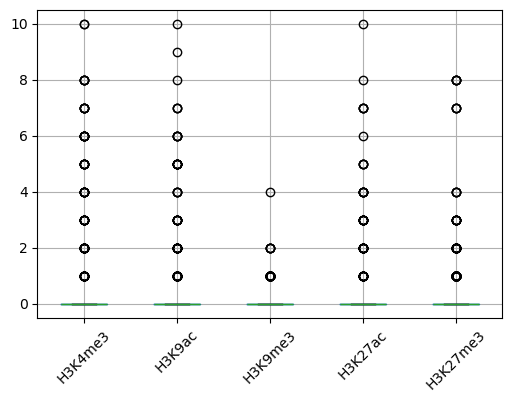

In [144]:
plt.figure(figsize=(6, 4))
histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

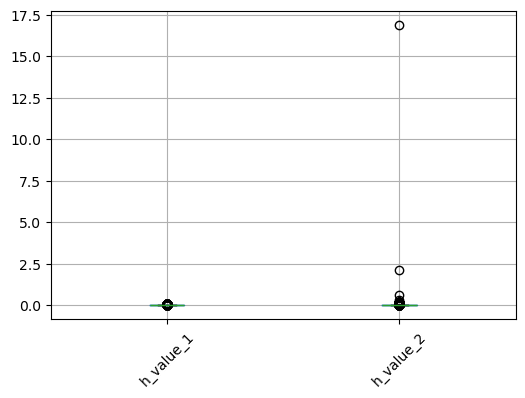

In [145]:
plt.figure(figsize=(6, 4))
histone_df_filtered[['h_value_1', 'h_value_2']].boxplot()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

## Scaling

In [70]:
## To be implemented
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [74]:
# Using original dataset
X = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y = histone_count_df[['h_value_1']]

In [75]:
# Train, test, split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# Transform the dataset
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

### Do another boxplot analysis

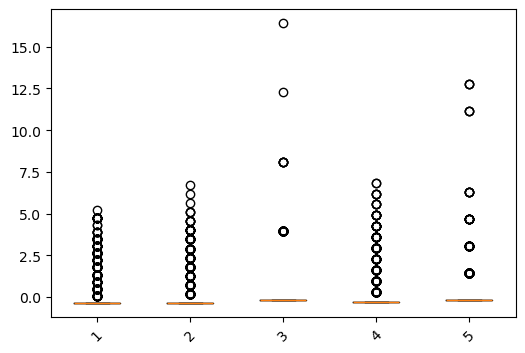

In [81]:
plt.figure(figsize=(6, 4))
plt.boxplot(X_train_scaled)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

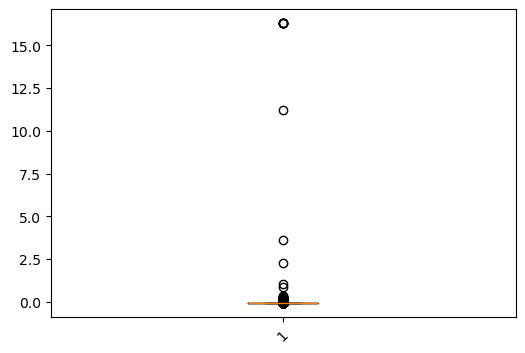

In [82]:
plt.figure(figsize=(6, 4))
plt.boxplot(y_train_scaled)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Modeling

## Original Dataset

In [98]:
# Using original dataset
X_orig = histone_count_df[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y_orig = histone_count_df[['h_value_1']]

In [131]:
# Train, test, split
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)

In [132]:
print(len(X_orig_train))
print(len(X_orig_test))

1750
438


### Simple Linear Regression

In [133]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_orig_train, y_orig_train)

# Make predictions on the test set
y_orig_pred = model.predict(X_orig_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_orig_test, y_orig_pred))

[22.8592267446475, 664.3014429118124, 25.77404591661566, -3.6056332235543636, inf, 21.970488937217745]


In [134]:
save_prediction(y_orig_test, y_orig_pred, "results/original_linear_regression.csv")

In [174]:
model.coef_

array([[ -1.93883469,  -2.32059334, -13.86785166,  14.48907029,
         -6.08434327]])

### Polynomial Regression

In [173]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X_orig)
X_train, X_test, y_train, y_test = train_test_split(poly_features, y_orig, test_size=0.2, random_state=42)

poly_reg_model = LinearRegression()
poly_reg_model.fit(X_train, y_train)

y_predict = poly_reg_model.predict(X_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_test, y_predict))

save_prediction(y_test, y_predict, "results/original_polynomial_regression.csv")

[23.53864606788063, 780.1870654883301, 27.93182889623109, -4.409073708541455, inf, 24.87437003536155]


In [175]:
poly_reg_model.coef_

array([[ -7.75621158,   1.32691281, -29.55632045,  -5.72706961,
        -17.82588432,  -0.27411949,   0.12073861,  17.68409077,
          5.04948793,   3.53025285,   0.26971654,  13.10788605,
         -2.95980272,   1.19982037,   6.19028764, -45.91709101,
         10.11151333,   0.98997721,  -3.59586072,   1.25032599]])

## Scaled Dataset

### Simple Linear Regression

In [83]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_train_scaled, y_train_scaled)

# Make predictions on the test set
y_orig_pred = model.predict(X_test_scaled)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_orig_test, y_orig_pred))

[1.7284177679657147, 146.95695793142113, 12.122580498038408, -0.01885951792413132, inf, 0.00811003421606987]


## Dataset without Outliers

In [21]:
# Using dataset without outliers
X_filtered = histone_df_filtered[['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']]
y_filtered = histone_df_filtered[['h_value_1']]

# Train, test, split
X_filtered_train, X_filtered_test, y_filtered_train, y_filtered_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)


In [22]:
print(len(X_filtered_train))
print(len(X_filtered_test))

1416
354


### Simple Linear Regression

In [176]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training set
model.fit(X_filtered_train, y_filtered_train)

# Make predictions on the test set
y_filtered_pred = model.predict(X_filtered_test)

# Evaluate the model
# [mae, mse, rmse, r2, mape, median_ae]
print(get_evaluation(y_filtered_test, y_filtered_pred))

[0.008210278317177624, 0.00019989205157471462, 0.014138318555426407, -0.006506924999586827, inf, 0.004162549550279487]


In [177]:
save_prediction(y_filtered_test, y_filtered_pred, "results/filtered_linear_regression.csv")